# RealTimeBath benchmark: semicircle, half-semicircle, and box

This notebook reproduces the three real-time hybridization tests on $t\in[0,10]$. It scans mode budgets $N=1,\ldots,15$ and compares:

- the 2506.10308 SDP construction followed by physical time-domain optimization;
- the 2604.06466 positive-exponential route.

For each target it shows the real and imaginary parts of $\Delta(t)$ at $N=6$, pointwise errors at $N=6$ and $N=12$, normalized $L^1$ error versus mode budget, and wall-clock timing. The unoptimized SDP curve is intentionally omitted. Timings are machine- and solver-dependent.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import trapezoid
from scipy.special import j1, struve

REPOSITORY_ROOT = Path.cwd()
if not (REPOSITORY_ROOT / "src").is_dir():
    REPOSITORY_ROOT = REPOSITORY_ROOT.parent
if (REPOSITORY_ROOT / "src").is_dir():
    sys.path.insert(0, str(REPOSITORY_ROOT / "src"))

from realtimebath import BandLimitError, fit_correlation
from realtimebath.route_sdp import cvxpy_available

if not cvxpy_available():
    raise RuntimeError("Install RealTimeBath with the sdp extra to run this notebook")

TIMES = np.linspace(0.0, 10.0, 501)
MODE_BUDGETS = np.arange(1, 16)
DISPLAY_MODE = 6
ERROR_MODES = (6, 12)
OPTIMIZATION_MAX_NFEV = 1_000

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

## Analytic targets

The full semicircle uses $W=10$ and $\Gamma=1$. The half-semicircle and box are normalized densities supported only on $0\leq\omega\leq1$.

In [2]:
def semicircle_delta(times: np.ndarray) -> np.ndarray:
    values = np.empty(times.size, dtype=np.complex128)
    values[0] = 5.0
    values[1:] = j1(10.0 * times[1:]) / times[1:]
    return values


def half_semicircle_delta(times: np.ndarray) -> np.ndarray:
    values = np.empty(times.size, dtype=np.complex128)
    zero = times == 0.0
    values[zero] = 1.0
    nonzero = times[~zero]
    values[~zero] = 2.0 * (j1(nonzero) - 1j * struve(1, nonzero)) / nonzero
    return values


def box_delta(times: np.ndarray) -> np.ndarray:
    return np.asarray(
        np.exp(-0.5j * times) * np.sinc(times / (2.0 * np.pi)),
        dtype=np.complex128,
    )


TARGETS = {
    "semicircle": {
        "title": r"Semicircle: $W=10$, $\Gamma=1$",
        "transform": semicircle_delta,
    },
    "half-semicircle": {
        "title": r"Half-semicircle: $4\sqrt{1-\omega^2}/\pi$, $0\leq\omega\leq1$",
        "transform": half_semicircle_delta,
    },
    "box": {
        "title": r"Box: $J(\omega)=1$, $0\leq\omega\leq1$",
        "transform": box_delta,
    },
}

assert semicircle_delta(TIMES)[0] == 5.0
assert half_semicircle_delta(TIMES)[0] == 1.0
assert box_delta(TIMES)[0] == 1.0

## Mode sweep

The normalized error is $\epsilon_1=\int|\Delta_{\rm fit}-\Delta|dt/\int|\Delta|dt$. If the Hankel numerical-rank ceiling is reached, larger requested budgets reuse the last supported fit and are marked as a rank-limited plateau. A one-mode call to each route is made before timing so solver initialization and license startup do not distort the first measured point.

In [3]:
def relative_l1(reference: np.ndarray, fitted: np.ndarray) -> float:
    return float(
        trapezoid(np.abs(fitted - reference), TIMES)
        / trapezoid(np.abs(reference), TIMES)
    )


def run_benchmark(name: str, target: dict) -> dict:
    exact = target["transform"](TIMES)
    records = []
    fits = {}
    last_fit = None
    rank_limit_message = None

    print(f"\n{name}")
    for budget in MODE_BUDGETS:
        if rank_limit_message is None:
            shared = dict(
                n_modes=int(budget),
                tolerance=1e-3,
                max_nfev=800,
                optimization_max_nfev=OPTIMIZATION_MAX_NFEV,
                optimization_max_points=251,
            )
            try:
                started = perf_counter()
                optimized = fit_correlation(
                    TIMES, exact, method="sdp", optimize=True, **shared
                )
                optimized_seconds = perf_counter() - started

                started = perf_counter()
                positive = fit_correlation(
                    TIMES, exact, method="positive", **shared
                )
                positive_seconds = perf_counter() - started
                current = {
                    "optimized": optimized.evaluate(TIMES),
                    "positive": positive.evaluate(TIMES),
                    "active_modes": int(budget),
                }
                last_fit = current
            except BandLimitError as error:
                if last_fit is None:
                    raise
                rank_limit_message = str(error)
                current = last_fit
                optimized_seconds = np.nan
                positive_seconds = np.nan
        else:
            current = last_fit
            optimized_seconds = np.nan
            positive_seconds = np.nan

        fits[int(budget)] = current
        record = {
            "budget": int(budget),
            "active_modes": current["active_modes"],
            "optimized_l1": relative_l1(exact, current["optimized"]),
            "positive_l1": relative_l1(exact, current["positive"]),
            "optimized_seconds": optimized_seconds,
            "positive_seconds": positive_seconds,
        }
        records.append(record)
        suffix = (
            " (rank-limited plateau)"
            if record["active_modes"] != record["budget"]
            else ""
        )
        print(
            f"N={budget:2d}, active={record['active_modes']:2d}: "
            f"L1={record['optimized_l1']:.3e}/{record['positive_l1']:.3e}, "
            f"time={optimized_seconds:.3f}/{positive_seconds:.3f} s{suffix}"
        )

    return {
        "name": name,
        "title": target["title"],
        "exact": exact,
        "records": records,
        "fits": fits,
        "rank_limit_message": rank_limit_message,
    }

In [4]:
warmup_target = semicircle_delta(TIMES)
warmup_options = dict(
    n_modes=1, tolerance=1e-3, max_nfev=800,
    optimization_max_nfev=OPTIMIZATION_MAX_NFEV, optimization_max_points=251,
)
_ = fit_correlation(TIMES, warmup_target, method="sdp", optimize=True, **warmup_options)
_ = fit_correlation(TIMES, warmup_target, method="positive", **warmup_options)

RESULTS = {name: run_benchmark(name, target) for name, target in TARGETS.items()}


semicircle


N= 1, active= 1: L1=4.872e-01/4.872e-01, time=0.190/0.141 s


N= 2, active= 2: L1=3.032e-01/3.032e-01, time=0.197/0.153 s


N= 3, active= 3: L1=1.637e-01/1.637e-01, time=0.193/0.219 s


N= 4, active= 4: L1=9.774e-02/9.774e-02, time=0.210/0.233 s


...

N= 3, active= 3: L1=5.915e-04/5.915e-04, time=0.131/0.132 s


N= 4, active= 4: L1=1.311e-05/1.311e-05, time=0.373/0.259 s


N= 5, active= 5: L1=3.412e-06/3.412e-06, time=0.176/0.201 s


N= 6, active= 6: L1=6.516e-07/6.516e-07, time=0.454/0.409 s


N= 7, active= 7: L1=9.607e-07/9.607e-07, time=0.435/0.432 s
N= 8, active= 7: L1=9.607e-07/9.607e-07, time=nan/nan s (rank-limited plateau)
N= 9, active= 7: L1=9.607e-07/9.607e-07, time=nan/nan s (rank-limited plateau)
N=10, active= 7: L1=9.607e-07/9.607e-07, time=nan/nan s (rank-limited plateau)
N=11, active= 7: L1=9.607e-07/9.607e-07, time=nan/nan s (rank-limited plateau)
N=12, active= 7: L1=9.607e-07/9.607e-07, time=nan/nan s (rank-limited plateau)
N=13, active= 7: L1=9.607e-07/9.607e-07, time=nan/nan s (rank-limited plateau)
N=14, active= 7: L1=9.607e-07/9.607e-07, time=nan/nan s (rank-limited plateau)
N=15, active= 7: L1=9.607e-07/9.607e-07, time=nan/nan s (rank-limited plateau)


## Fits, pointwise errors, $L^1$ convergence, and timing

In [5]:
COLORS = {"optimized": "#1f77b4", "positive": "#e87500"}
LABELS = {
    "optimized": "2506.10308: SDP + time optimization",
    "positive": "2604.06466: positive exponential",
}
STYLES = {"optimized": "-", "positive": "--"}


def plot_benchmark(result: dict) -> None:
    exact = result["exact"]
    records = result["records"]
    budgets = np.array([row["budget"] for row in records])
    active = np.array([row["active_modes"] for row in records])
    primary = result["fits"][DISPLAY_MODE]

    figure = plt.figure(figsize=(14.5, 7.2), constrained_layout=True)
    grid = figure.add_gridspec(2, 3, width_ratios=(1.0, 1.0, 1.15))
    real_axis = figure.add_subplot(grid[0, 0])
    imag_axis = figure.add_subplot(grid[1, 0], sharex=real_axis)
    residual_axes = (
        figure.add_subplot(grid[0, 1], sharex=real_axis),
        figure.add_subplot(grid[1, 1], sharex=real_axis),
    )
    l1_axis = figure.add_subplot(grid[:, 2])

    real_axis.plot(TIMES, exact.real, color="black", lw=2, label="exact")
    imag_axis.plot(TIMES, exact.imag, color="black", lw=2, label="exact")
    for route in ("optimized", "positive"):
        real_axis.plot(
            TIMES, primary[route].real, STYLES[route],
            color=COLORS[route], lw=1.5, label=LABELS[route],
        )
        imag_axis.plot(
            TIMES, primary[route].imag, STYLES[route],
            color=COLORS[route], lw=1.5, label=LABELS[route],
        )

    for budget, axis in zip(ERROR_MODES, residual_axes):
        fit = result["fits"][budget]
        for route in ("optimized", "positive"):
            axis.semilogy(
                TIMES, np.maximum(np.abs(fit[route] - exact), 1e-15),
                STYLES[route], color=COLORS[route], lw=1.5, label=LABELS[route],
            )
        title = f"Pointwise absolute error, N={budget}"
        if fit["active_modes"] != budget:
            title += f" ({fit['active_modes']} active)"
        axis.set_title(title)
        axis.set_ylabel(r"$|\Delta_{\rm fit}(t)-\Delta(t)|$")

    for route, marker in (("optimized", "o"), ("positive", "s")):
        l1_axis.semilogy(
            budgets, [row[f"{route}_l1"] for row in records],
            STYLES[route] + marker, color=COLORS[route], label=LABELS[route],
        )
    ceiling = int(np.max(active))
    if ceiling < int(np.max(budgets)):
        l1_axis.axvspan(ceiling + 0.5, budgets[-1] + 0.5, color="#eeeeee", zorder=-1)
        l1_axis.text(
            ceiling + 0.7, 0.02, f"rank-limited:\n{ceiling} active modes",
            transform=l1_axis.get_xaxis_transform(), fontsize=8, color="#555555",
        )

    real_axis.set_title(f"Real part, N={DISPLAY_MODE}")
    imag_axis.set_title(f"Imaginary part, N={DISPLAY_MODE}")
    real_axis.set_ylabel(r"Re $\Delta(t)$")
    imag_axis.set_ylabel(r"Im $\Delta(t)$")
    l1_axis.set_title(r"Normalized $L^1$ error")
    l1_axis.set_ylabel(r"$\int|\Delta_{\rm fit}-\Delta|dt/\int|\Delta|dt$")
    l1_axis.set_xlabel("mode budget N")
    l1_axis.set_xticks(budgets)
    for axis in (real_axis, imag_axis, *residual_axes):
        axis.set_xlabel("t")
        axis.set_xlim(0.0, 10.0)
    real_axis.legend(fontsize=8)
    l1_axis.legend(fontsize=8)
    figure.suptitle(result["title"] + r", fit window $t\in[0,10]$", fontsize=14)
    plt.show()

    timing_figure, timing_axis = plt.subplots(figsize=(7.4, 4.5), constrained_layout=True)
    for route, marker in (("optimized", "o"), ("positive", "s")):
        timing_axis.semilogy(
            budgets, [row[f"{route}_seconds"] for row in records],
            STYLES[route] + marker, color=COLORS[route], label=LABELS[route],
        )
    if ceiling < int(np.max(budgets)):
        timing_axis.axvspan(ceiling + 0.5, budgets[-1] + 0.5, color="#eeeeee", zorder=-1)
    timing_axis.set(
        title=result["title"] + " fitting time",
        xlabel="mode budget N", ylabel="wall-clock time (seconds)", xticks=budgets,
    )
    timing_axis.legend(fontsize=8)
    plt.show()

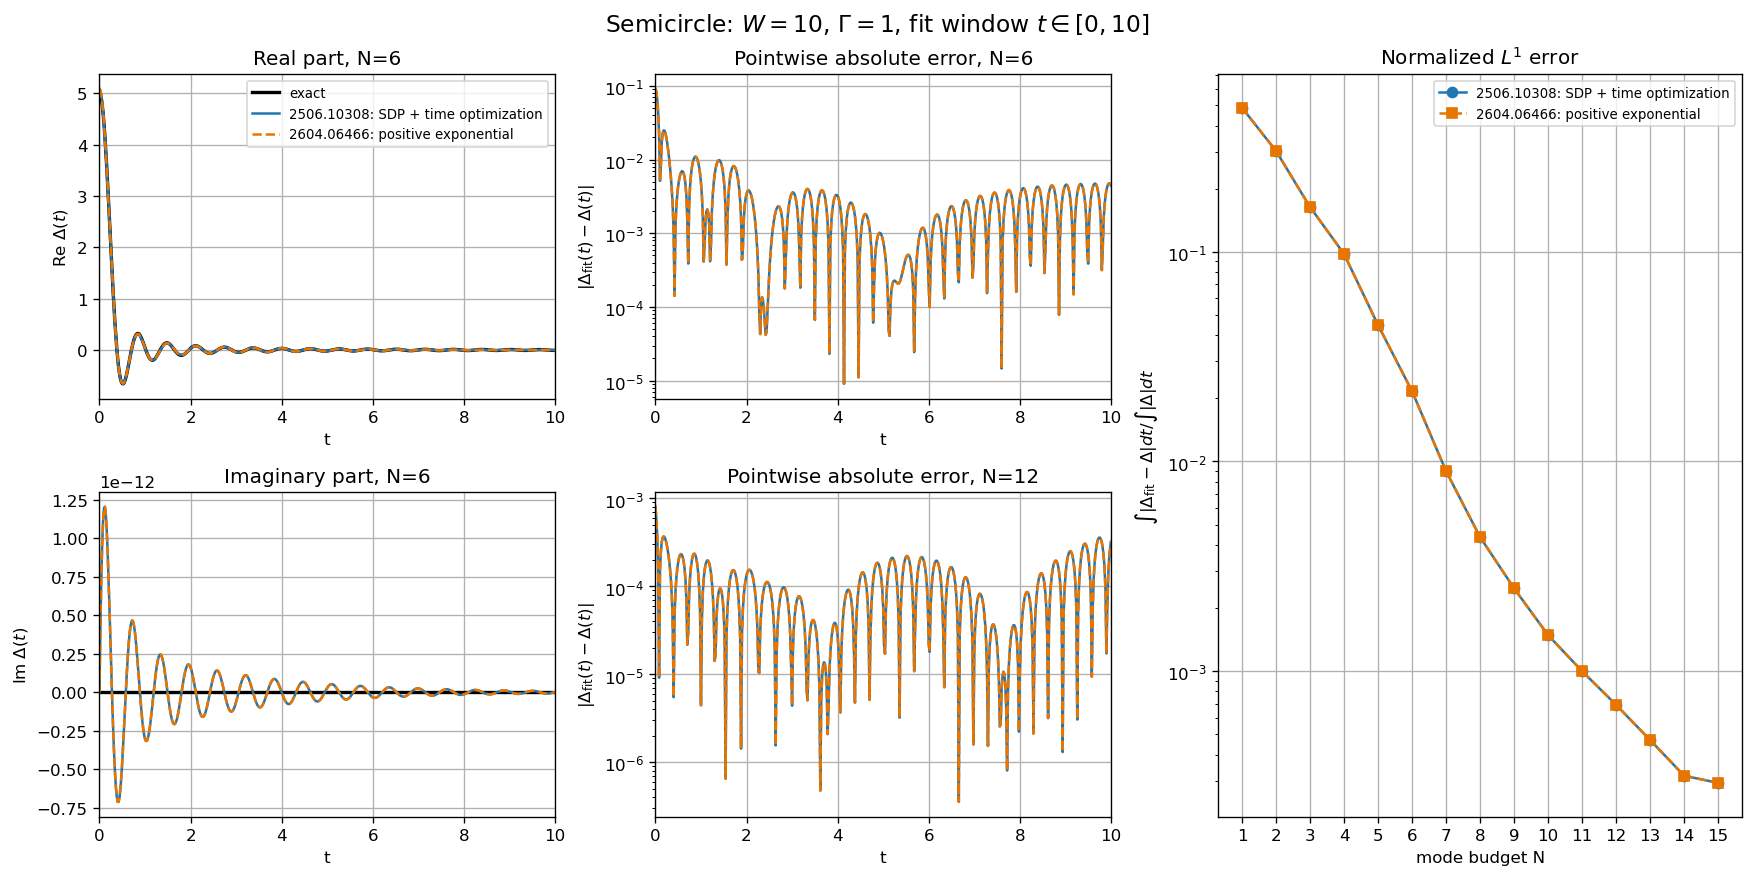

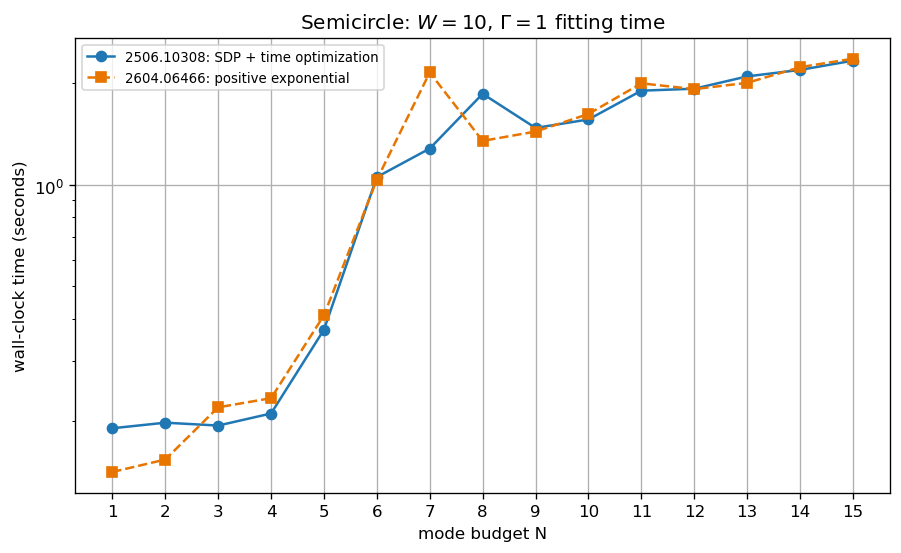

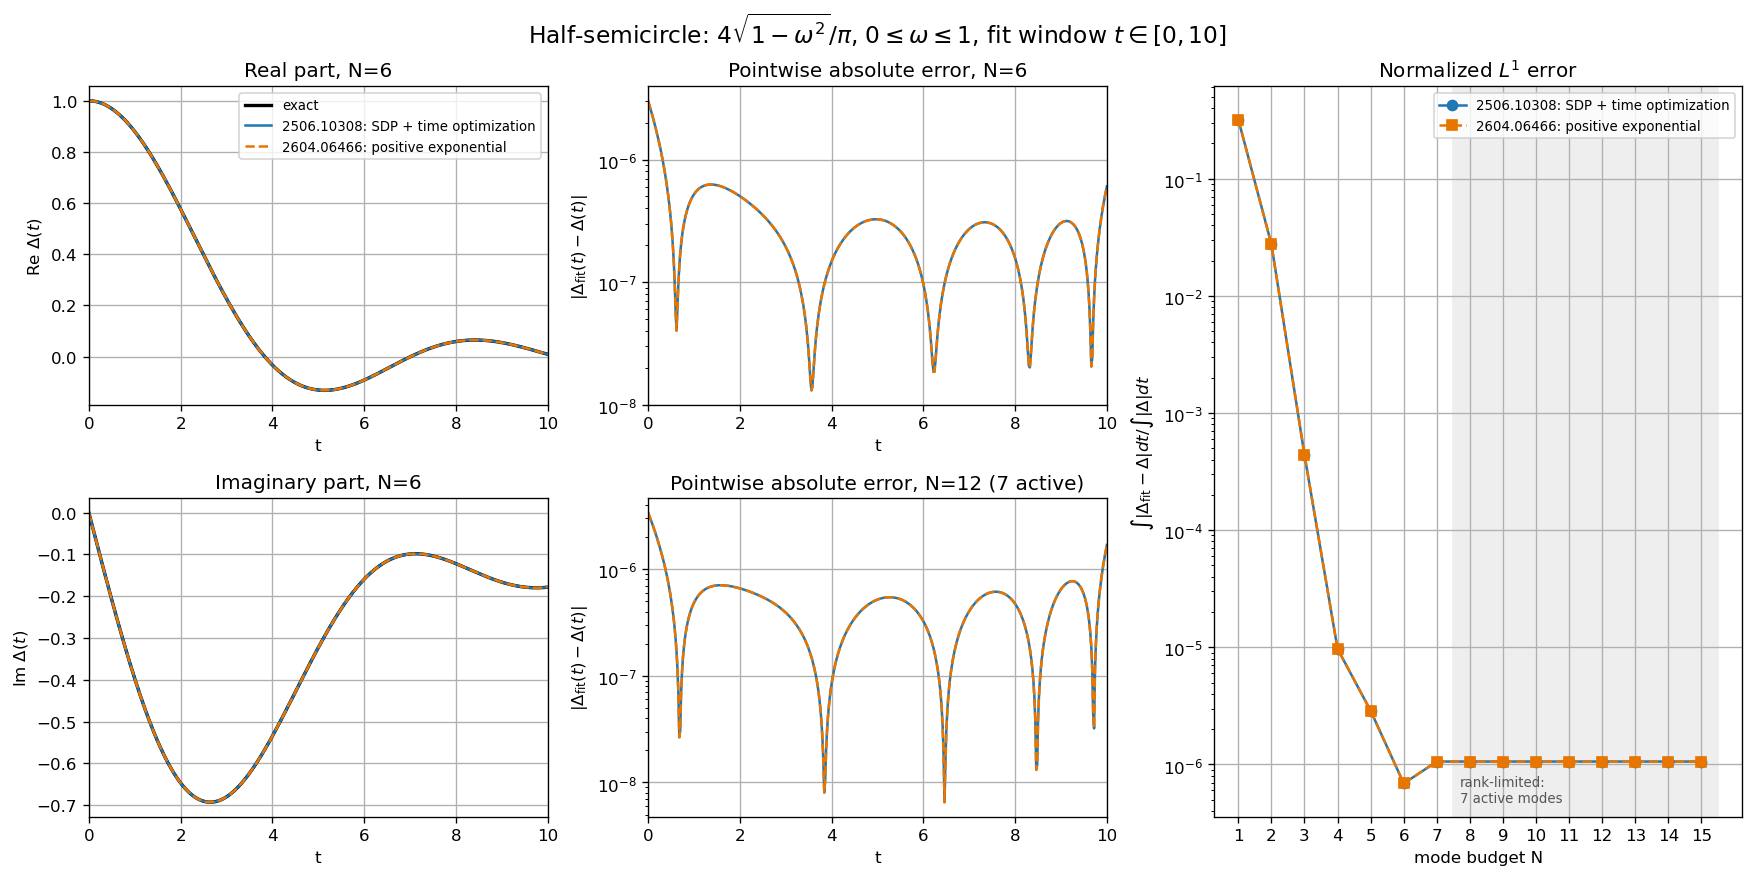

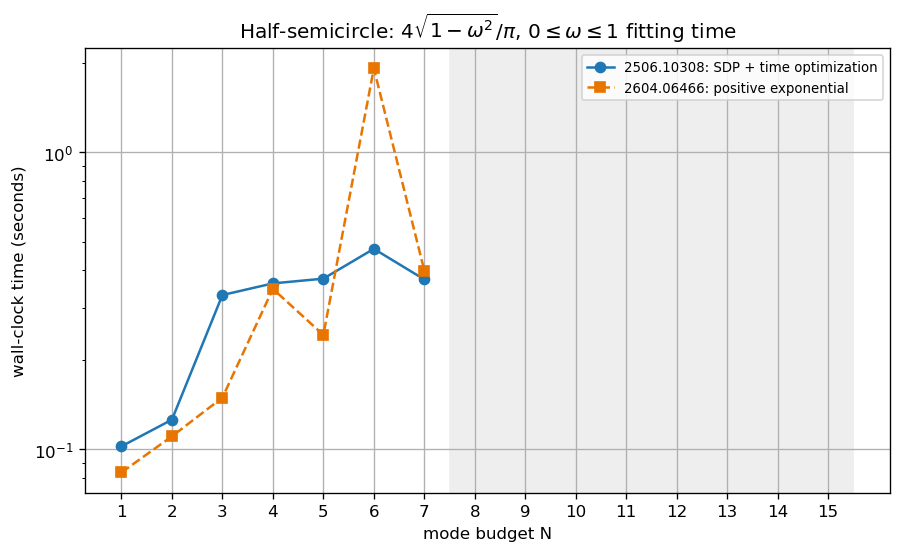

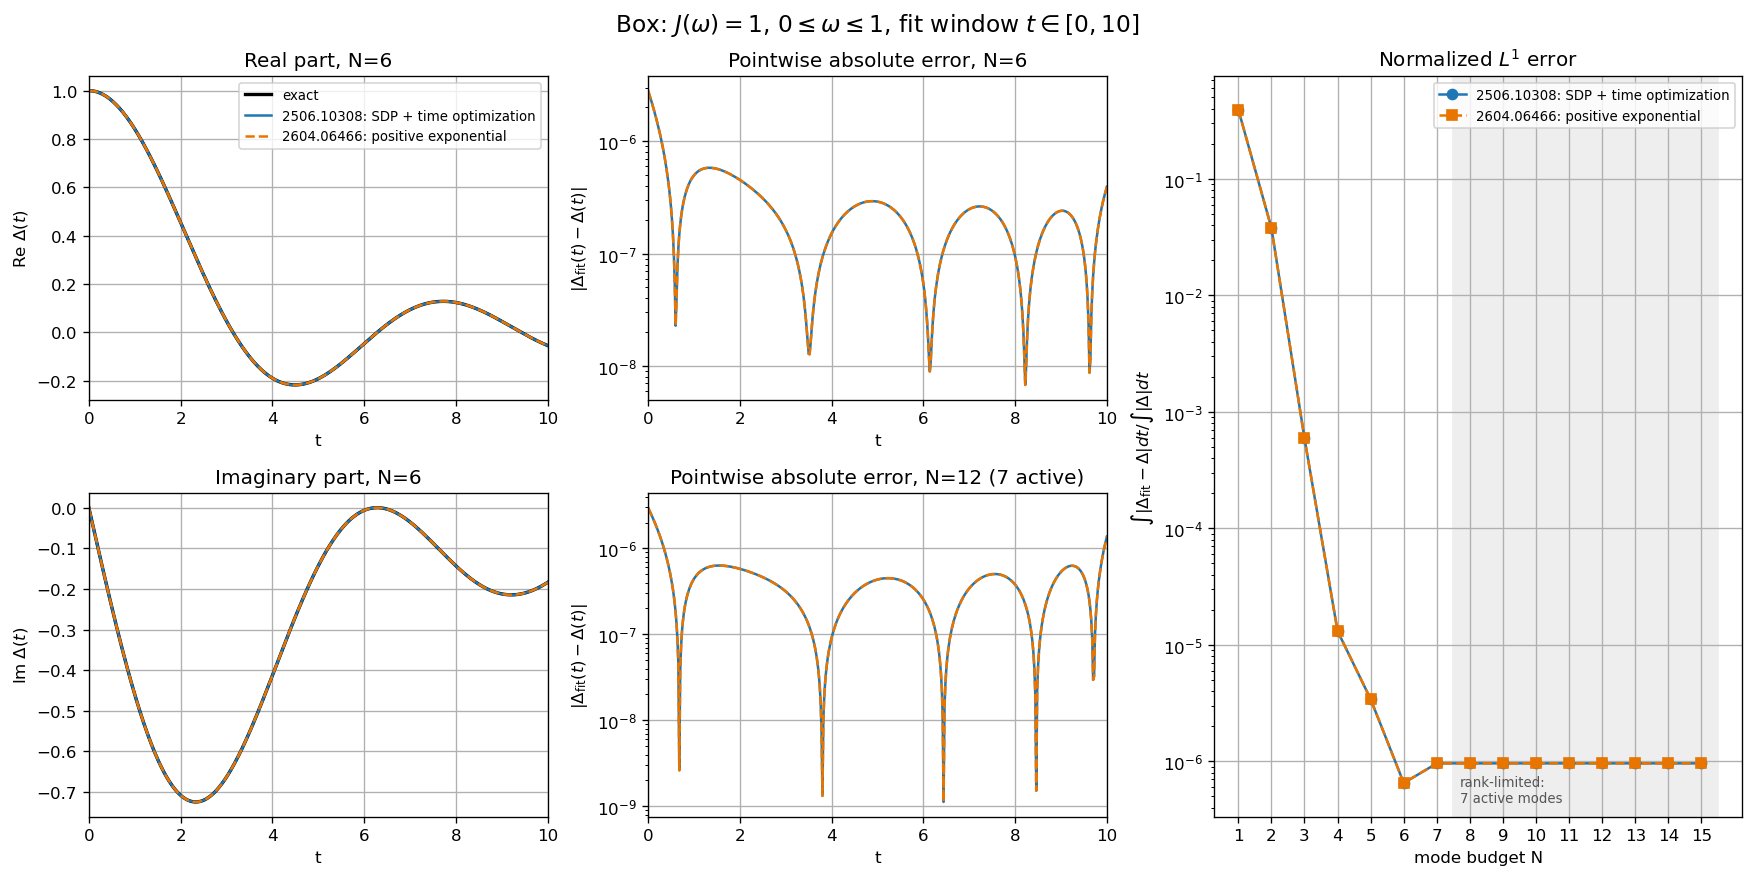

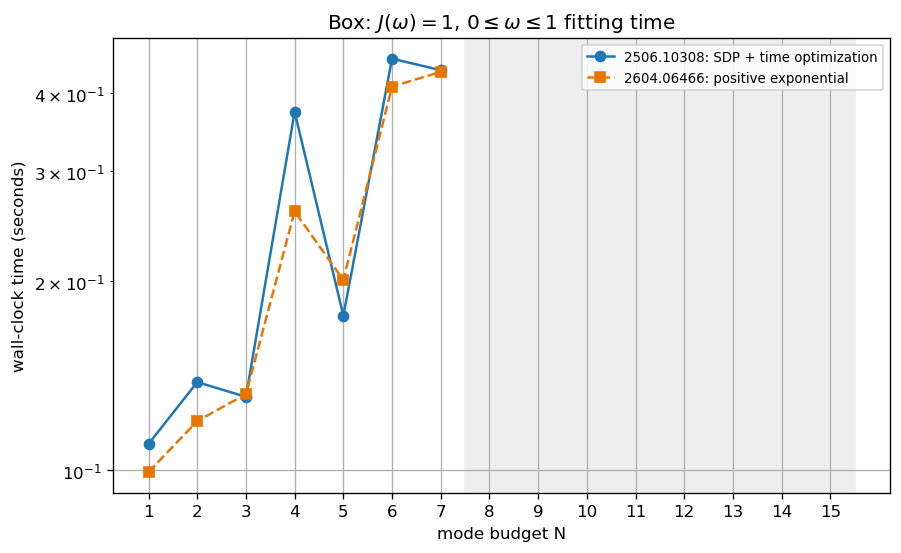

In [6]:
for result in RESULTS.values():
    plot_benchmark(result)

## Compact numerical summary

In [7]:
for name, result in RESULTS.items():
    print(f"\n{name}")
    print("budget active  SDP+opt L1   positive L1   SDP+opt s   positive s")
    for row in result["records"]:
        print(
            f"{row['budget']:>6d} {row['active_modes']:>6d}  "
            f"{row['optimized_l1']:>11.4e} {row['positive_l1']:>13.4e}  "
            f"{row['optimized_seconds']:>10.3f} {row['positive_seconds']:>12.3f}"
        )
    if result["rank_limit_message"]:
        print(result["rank_limit_message"])

assert set(RESULTS) == {"semicircle", "half-semicircle", "box"}
assert all(len(result["records"]) == 15 for result in RESULTS.values())
assert all(
    np.isfinite(row["optimized_l1"]) and np.isfinite(row["positive_l1"])
    for result in RESULTS.values() for row in result["records"]
)


semicircle
budget active  SDP+opt L1   positive L1   SDP+opt s   positive s
     1      1   4.8720e-01    4.8720e-01       0.190        0.141
     2      2   3.0324e-01    3.0324e-01       0.197        0.153
     3      3   1.6373e-01    1.6373e-01       0.193        0.219
     4      4   9.7740e-02    9.7740e-02       0.210        0.233
     5      5   4.4775e-02    4.4775e-02       0.372        0.410
     6      6   2.1643e-02    2.1643e-02       1.053        1.035
     7      7   8.9937e-03    8.9937e-03       1.280        2.150
     8      8   4.3594e-03    4.3594e-03       1.859        1.348
     9      9   2.4801e-03    2.4801e-03       1.473        1.437
    10     10   1.4842e-03    1.4842e-03       1.560        1.620
    11     11   9.9828e-04    9.9828e-04       1.899        1.996
    12     12   6.8996e-04    6.8996e-04       1.924        1.919
    13     13   4.6876e-04    4.6876e-04       2.093        2.003
    14     14   3.1670e-04    3.1670e-04       2.188        2.229